# 第4回 — 学習の深掘り ＋ 評価 ＋ チューニング大会

**今日のゴール**: `check_eval` を PASS させる ＋ leaderboard に1回以上申告する．

| パート | 内容 | 時間 |
|---|---|---|
| ハンズオン① | 学習経過の記録・可視化 → 曲線の読み方 → overfit/underfit・early stopping・scheduler・seed | 30分 |
| ハンズオン② | predict を書く → confusion matrix → classification_report | 20分 |
| チューニング大会 | 各自チューニング → evaluate → leaderboard 申告 | 15分 |

> 前提: 第3回の学習（`uv run python -m kws.train ...`）で `exp/baseline/best.pt` が作られていること．

## 全体の流れ

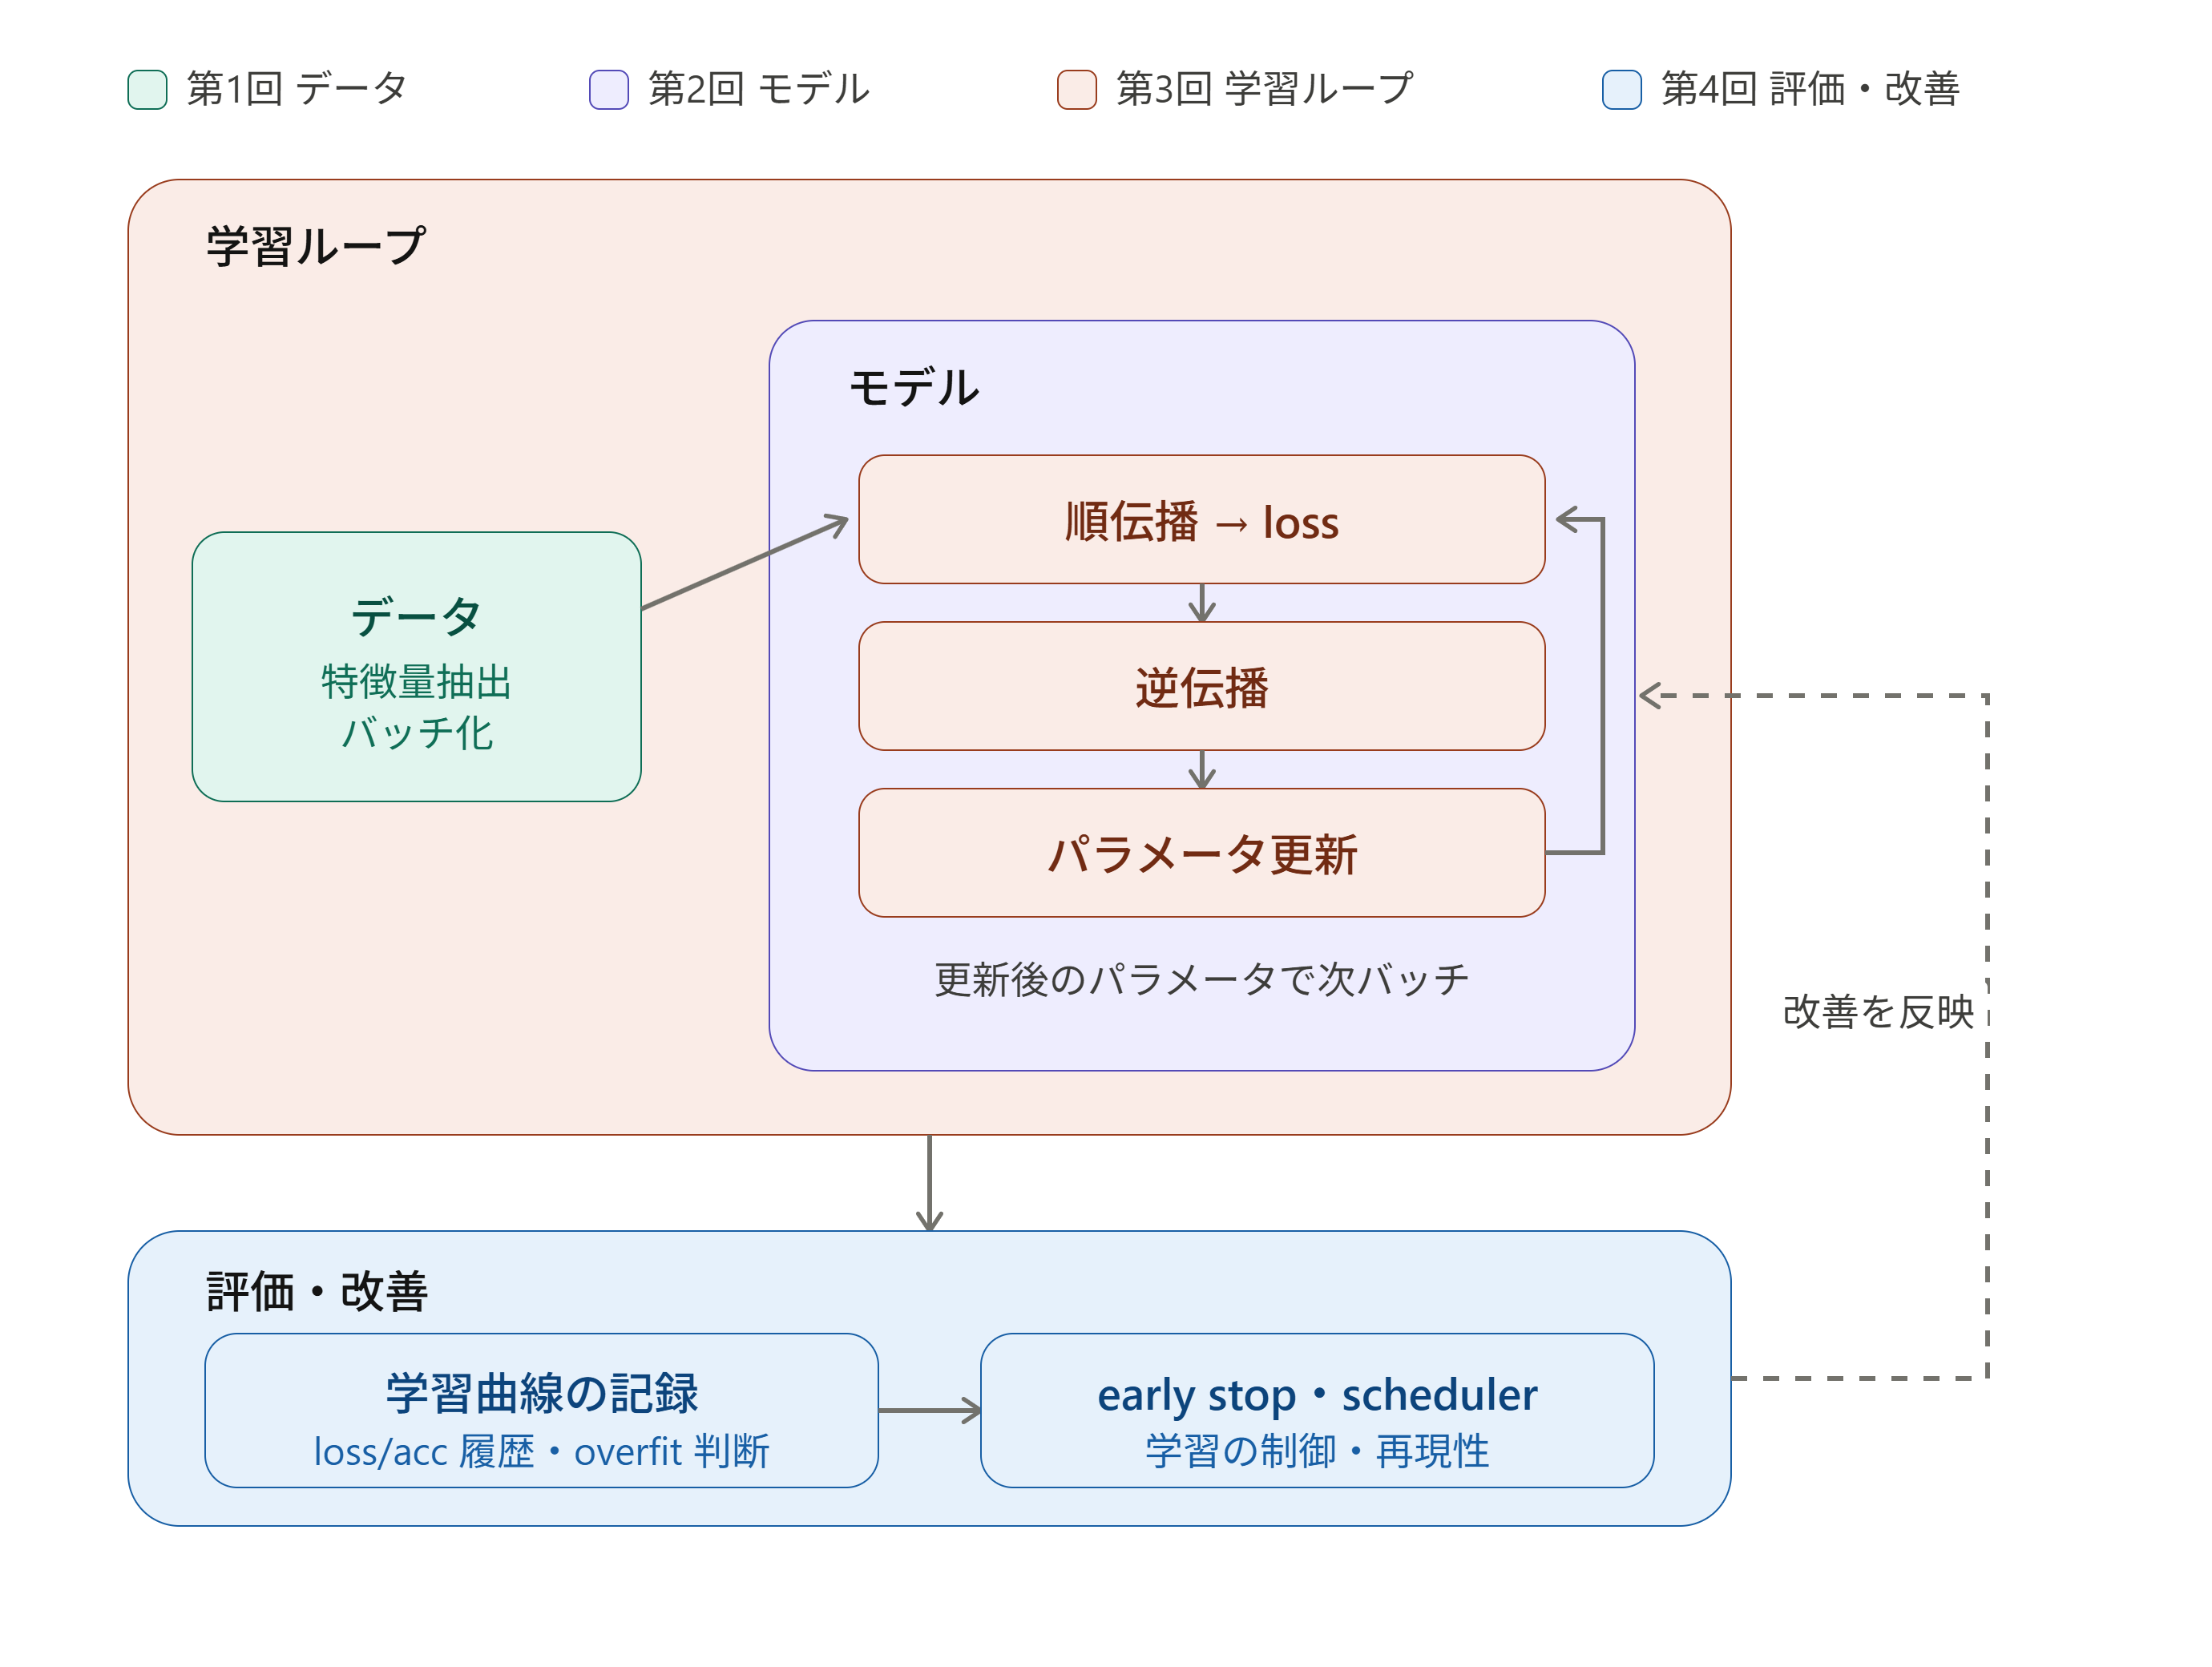

- 図の4色のブロックが，それぞれ第1〜4回に対応する．
- 今回（第4回）は青のブロック「評価・改善」で，図中の「改善を反映」の矢印にあたる部分．
- 学習曲線を記録して過学習を診断し，early stopping と scheduler で次の学習に改善を反映する．
- 最後に confusion matrix と `classification_report` で最終精度を確認．


In [ ]:
import os, sys
from pathlib import Path
if Path.cwd().name == "materials":
    os.chdir("..")
sys.path.insert(0, "src")
import json, numpy as np, torch, matplotlib.pyplot as plt
from torch import nn
from kws.data import LABELS, get_dataloaders
from kws.model import AudioCNN
from kws.train import run_epoch
from kws.utils import set_seed
dev = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", dev, "| num classes:", len(LABELS))

## ハンズオン① — 学習経過の記録・可視化（30分）

第3回は `print` しかしていないのでログが残らなかった．今回はまずこれを解決する．

### 学習経過の記録

`history` リストに epoch ごとの loss と accuracy を追記して，最後に `history.json` に書き出す．
学習が途中で止まっても経過が残るので便利．

In [ ]:
set_seed(42)
loaders = get_dataloaders('data', batch_size=256, n_mels=64, num_workers=4)
model = AudioCNN(n_classes=35, base=32).to(dev)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = []
for epoch in range(1, 16):
    tr_loss, tr_acc = run_epoch(model, loaders['train'], criterion, dev, optimizer)
    va_loss, va_acc = run_epoch(model, loaders['val'], criterion, dev, None)
    print(f"epoch {epoch:2d}: train loss {tr_loss:.3f} acc {tr_acc:.3f} | val loss {va_loss:.3f} acc {va_acc:.3f}")
    history.append({'epoch': epoch, 'train_loss': tr_loss, 'train_acc': tr_acc,
                    'val_loss': va_loss, 'val_acc': va_acc})

with open('history.json', 'w') as f:
    json.dump(history, f, indent=2)
print("history.json に保存した")

### loss 曲線の描画

記録した `history` を matplotlib で描画して `loss_curve.png` に保存する．

In [ ]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
ep = [h['epoch'] for h in history]
a1.plot(ep, [h['train_loss'] for h in history], 'o-', label='train')
a1.plot(ep, [h['val_loss'] for h in history], 's-', label='val')
a1.set_xlabel('epoch'); a1.set_ylabel('loss'); a1.legend(); a1.grid(alpha=0.3)
a2.plot(ep, [h['train_acc'] for h in history], 'o-', label='train')
a2.plot(ep, [h['val_acc'] for h in history], 's-', label='val')
a2.set_xlabel('epoch'); a2.set_ylabel('accuracy'); a2.legend(); a2.grid(alpha=0.3)
fig.tight_layout(); fig.savefig('loss_curve.png', dpi=150); plt.show()
print("loss_curve.png に保存した")

これで「第3回の問題＝ログが残らない」は解決した．
学習曲線の監視には tensorboard や wandb といったツールもあるが，今回は `history.json` + `loss_curve.png` で十分．

### 学習曲線の読み方

描いた `loss_curve.png` を全員で読んでみる：

| 状況 | 意味 |
|---|---|
| train loss↓ / val loss も↓ | まだ学習が進んでいる．epoch を増やす余地がある |
| train loss↓ / val loss↑ | **過学習**．モデルが訓練データに特化しすぎている |
| train loss が高止まり | **未学習**．モデルの容量が足りないか，学習率が合っていない |

弱ベースラインの15 epoch では，train loss は下がるが val loss は途中から横ばい〜微増するはず．
「train は良くなっているのに val は良くならない＝過学習が始まっている」ことを確認しよう．

### early stopping

val loss が改善しなくなったら学習を止める仕組み．patience（何 epoch 待つか）を決めて使う．

`train.py` は `best.pt` と `last.pt` の2種類を保存する設計になっている．`best.pt` は val accuracy が
最良だったエポックの重みで，結果的に early stopping と近い効果がある．ただし best.pt 方式は最後まで
回してから最良の重みだけ採用するので計算コストは変わらない点が違う．

「なぜ `last.pt` ではなく `best.pt` を推論に使うのか」：過学習が進んだ後の last より，val が最良だった
best のほうが汎化性能が高い．

### lr scheduler

`train.py` にはすでに `scheduler: cosine` のフックがある．
`configs/baseline.yaml` の `scheduler: null` を `cosine` に変えるだけで CosineAnnealingLR が有効になる．

**CosineAnnealingLR** は学習率を余弦カーブで徐々に下げていく．学習の後半ほど小さなステップで
パラメータを微調整する．下で実際の lr の動き方を見てみよう．

In [ ]:
dummy_opt = torch.optim.SGD([torch.zeros(1, requires_grad=True)], lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(dummy_opt, T_max=25)
lrs = []
for _ in range(25):
    lrs.append(dummy_opt.param_groups[0]["lr"])
    dummy_opt.step()
    sched.step()

plt.figure(figsize=(6, 3))
plt.plot(range(1, 26), lrs, 'o-')
plt.xlabel('epoch'); plt.ylabel('learning rate')
plt.title('CosineAnnealingLR (lr=1e-3, T_max=25)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### seed と再現性

`set_seed(42)` で乱数を固定しているので，同じ設定で回せば同じ結果が再現する．
seed を変えると結果が微妙に変わることも確認してみよう．

In [ ]:
set_seed(42)
a = torch.randn(3)
set_seed(42)
b = torch.randn(3)
print("seed 固定で同じ乱数:", torch.allclose(a, b))

set_seed(123)
c = torch.randn(3)
print("seed を変えると異なる乱数:", not torch.allclose(a, c))

## ハンズオン② — テスト評価（20分）

`predict` 関数を書いて confusion matrix を出し，どのクラスを間違えるかを分析する．

### checkpoint を読み込む

`best.pt` には `model`（重み）と `config`（学習設定）が入っている．
config から `base` を読んで同じ形のモデルを作り，重みを流し込む．

In [ ]:
ckpt = torch.load('exp/baseline/best.pt', map_location=dev, weights_only=False)
base = ckpt.get('config', {}).get('base', 32)
model = AudioCNN(n_classes=35, base=base).to(dev)
model.load_state_dict(ckpt['model'])
print("best epoch:", ckpt.get('epoch'), "| val best_acc:", round(ckpt.get('best_acc', 0), 4))

### predict 関数を書く（穴埋め）

各バッチの予測クラスと正解ラベルを集めて返す関数を完成させよう．

```python
@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    ys, ps = [], []
    for feats, targets in loader:
        feats = feats.to(device)
        logits = model(feats)
        # ここが今日書く部分
        ...
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()
```

やるべきことは2行だけ：
- `logits` は `(batch, 35)` の shape．axis=1 が クラス方向なので `argmax(1)` でサンプルごとに最も
  確率が高いクラスの index を取る．`.cpu()` で CPU に戻す
- 正解ラベルも `.cpu()` を明示しておくと device を気にしなくてよい

In [ ]:
@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    ys, ps = [], []
    for feats, targets in loader:
        feats = feats.to(device)
        logits = model(feats)
        # TODO: 予測クラスを ps に追加する（logits の argmax を .cpu() で）
        # TODO: 正解ラベルを ys に追加する（.cpu() で）
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()

### 書けたら動作確認

In [ ]:
loaders = get_dataloaders('data', batch_size=256, n_mels=64, num_workers=4)
y_true, y_pred = predict(model, loaders['test'], dev)
print(f"test samples: {len(y_true)}, accuracy: {(y_true == y_pred).mean():.3f}")

### classification_report

全体 accuracy だけでは見えない「特定のクラスだけ極端に弱い」といった問題が
クラス別の precision / recall / F1 で分かる．

- **precision**：そのクラスだと予測したうち実際に正解だった割合
- **recall**：そのクラスの正解のうち見つけられた割合
- **F1**：precision と recall の調和平均

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=LABELS, digits=3))

### confusion matrix

行=正解，列=予測．対角線に数字が集中しているほど正しい予測が多い．
対角から外れた濃いマスが「混同しているクラス対」．

`plot_confusion` は `kws.evaluate` に用意済みなので呼ぶだけ．

In [ ]:
from sklearn.metrics import confusion_matrix
from kws.evaluate import plot_confusion

cm = confusion_matrix(y_true, y_pred, labels=range(35))
print(f"confusion matrix shape: {cm.shape}")  # (35, 35) になるはず

acc = float((y_true == y_pred).mean())
plot_confusion(cm, acc, Path('confusion_matrix.png'))
print("confusion_matrix.png に保存した")

### どのクラス対が混同しやすい？

非対角成分が大きい順に並べると，似た音（例: go/no, three/tree など）が見える．

In [ ]:
cm0 = cm.copy()
np.fill_diagonal(cm0, 0)
pairs = [(LABELS[i], LABELS[j], cm0[i, j])
         for i in range(len(LABELS)) for j in range(len(LABELS)) if cm0[i, j] > 0]
pairs.sort(key=lambda t: t[2], reverse=True)
print("混同が多い (true -> pred) 上位:")
for t, p, n in pairs[:10]:
    print(f"  {t:>8} -> {p:<8} : {n}")

### check_eval — PASS で評価パイプライン完成

以下のセルを実行して全 assert が通れば今日のハンズオン② は完了．

In [ ]:
"""evaluate モジュールの確認：predict が動く・出力サイズが正しい・confusion matrix が 35×35 を assert する．"""
import sys
import torch
import numpy as np

sys.path.insert(0, "src")
from kws.data import LABELS, get_dataloaders
from kws.model import AudioCNN
from kws.utils import get_device

from kws.utils import set_seed
set_seed(42)

device = get_device()
ckpt = torch.load('exp/baseline/best.pt', map_location=device, weights_only=False)
model = AudioCNN(n_classes=35, base=ckpt.get('config', {}).get('base', 32)).to(device)
model.load_state_dict(ckpt['model'])

loaders = get_dataloaders('data', batch_size=256, n_mels=64, num_workers=4)
y_true, y_pred = predict(model, loaders['test'], device)

# --- 1. 出力長が test 件数と一致するか ---
n_test = sum(len(t) for _, t in loaders['test'])
assert len(y_true) == n_test, f"y_true の長さ {len(y_true)} が test 件数 {n_test} と一致しない"
assert len(y_pred) == n_test, f"y_pred の長さ {len(y_pred)} が test 件数 {n_test} と一致しない"

# --- 2. confusion matrix が 35×35 か ---
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred, labels=range(35))
assert cm.shape == (35, 35), f"confusion matrix の shape が {cm.shape}，35×35 であるべき"

# --- 3. test accuracy が出るか ---
acc = float((y_true == y_pred).mean())
assert acc > 0.10, f"test accuracy {acc:.3f} がチャンスレートに近すぎる"

print(f"check_eval PASS: test_acc {acc:.3f}, samples {n_test}, cm shape {cm.shape}")

## チューニング大会（15分）

道具が全部揃ったので，各自その場でチューニングして弱ベースライン超えを狙おう．

### ルール

- **指標は test accuracy**．各自 `predict` → `(y_true == y_pred).mean()` で算出する
- **test split は torchaudio 公式で全員共通固定**．全員が同じテストセットで評価するので比較可能
- 弄ってよいもの：学習率・epoch 数・モデル幅 `base`・`scheduler`・`augment`・モデル構造など何でも
- **Slack の #kws-leaderboard チャンネルに申告**する：名前・test accuracy・何を変えたかの一言メモ
- **seed cherry-picking の禁止**：seed だけ変えて最良の結果を申告するのは NG．変更点を明記する

### チューニングのヒント

- **まず容量を増やす**：`base=32` → `base=64` にするだけで精度がかなり上がるはず（**最初に試すべき変更**）
- **epoch を増やす**：`epochs=25` → `epochs=50` 等．`best.pt` 採用なので過学習しても最良の重みが残る
- **学習率を変える**：`lr=3e-4` や `lr=5e-4` を試してみる
- **scheduler を有効にする**：`scheduler: cosine` に変えてみる
- **モデル構造を変える**：ConvBlock の段数を増やす・Dropout を入れる等
- **Data Augmentation**：時間方向のシフト・ノイズ付加・SpecAugment 等

### 進め方

```bash
# 1. config をコピーして設定を変える
cp configs/baseline.yaml configs/my_exp.yaml
# (my_exp.yaml を編集して base=64, scheduler: cosine 等を設定)

# 2. 学習する
uv run python -m kws.train --config configs/my_exp.yaml --device cuda --run-name my_exp

# 3. 評価して accuracy を出す
#    → notebook の predict セルで exp/my_exp/best.pt を読み込む
```

GPU 環境で `base=32` / 25 epoch の学習は約5分．`base=64` にすると約10分．
15分のチューニング枠では1回のトライが現実的なので，まず `base=64` を試すのがおすすめ．
続きは宿題で．

## まとめ

### 今日やったこと

- ハンズオン①：`history.json` + `loss_curve.png` で学習曲線を可視化した
  - overfit/underfit の読み取り方・early stopping・lr scheduler・seed の話をした
- ハンズオン②：`predict` を書いて confusion matrix を出し，どのクラスを間違えるか分析した
  - `check_eval` PASS で評価パイプライン完成
- チューニング大会：各自の工夫でベースライン超えに挑戦した

### 全4回の振り返り

data → model → train → eval と積み上げて，「PyTorch で学習・評価スクリプトを自分で書ける」
という大目標に到達した．同じパイプラインが画像分類・テキスト分類・その他のタスクにも使える．

### 宿題

1. **`evaluate.py` に移植して整理**：当日 notebook で書いた `predict` を `src/kws/evaluate.py` の
   TODO に埋め，CLI で動かす：
   ```bash
   uv run python -m kws.evaluate --ckpt exp/baseline/best.pt --device cuda
   ```
   `confusion_matrix.png` と `test_metrics.json` が出力されれば OK．
2. **チューニングを続ける**：当日中に終わらなかった人はチューニングを続けて，Slack に最高記録を申告する．
3. **整理**：`check_eval` の PASS 結果＋チューニングで試したこと＋学んだことをまとめる．